# W03 — CSP Feature Pipeline

## Goal

Transfer the **Common Spatial Patterns (CSP)** idea from EEG motor-imagery analysis to multi-channel robot sensor data.

This notebook:

1. loads the Week 2 higher-frequency robot sensor stream,
2. selects two operational modes (**PATROL vs FAULT** by default),
3. windows the multichannel time series,
4. computes class-conditional covariance matrices from scratch,
5. solves the generalized eigenvalue problem using NumPy,
6. applies CSP spatial filters,
7. extracts log-variance CSP features,
8. compares raw-feature and CSP-feature separability,
9. saves the feature matrices for the Week 3 LDA notebook.

> **Important:** CSP requires multiple time samples within each window. Therefore, this notebook is intended to use the higher-frequency Week 2 sensor stream rather than treating individual 5-minute fleet-telemetry rows as CSP samples.


In [28]:
# Imports

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler


## 1. Configuration

Update `DATA_PATH` only if your Week 2 high-frequency CSV has a different filename/location.

The notebook first checks several likely Week 2 paths automatically.


In [29]:
# -----------------------------
# Configuration
# -----------------------------

FS = 20.0                 # Week 2 high-frequency stream sampling rate (Hz)
WINDOW_SEC = 5.0          # Change only if your Week 2 EDA used a different value
OVERLAP = 0.50            # 50% overlap; change only if Week 2 established another value

CLASS_A = "PATROL"
CLASS_B = "FAULT"

# Keep the channels that behave like simultaneous continuous sensor measurements.
# The code below will keep only columns that actually exist in the CSV.
CANDIDATE_CHANNELS = [
    "imu_x", "imu_y", "imu_z",
    "accel_x", "accel_y", "accel_z",
    "motor_current",
    "proximity",
    "rssi",
    "battery_soc"
]


DATA_PATH = "../data/robot_sensor_highfreq.csv"

print("Using data path:", DATA_PATH)
print("Window samples:", int(WINDOW_SEC * FS))
print("Step samples:", int(WINDOW_SEC * FS * (1 - OVERLAP)))


Using data path: ../data/robot_sensor_highfreq.csv
Window samples: 100
Step samples: 50


## 2. Load Week 2 sensor data

The code tries to detect common column names for:

- operational-mode label,
- robot/unit ID,
- time.

If your Week 2 column names are different, edit the small mapping cell below rather than changing the CSP implementation.


In [30]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())


Shape: (48000, 8)


,time,mode,motor_current,accel_x,accel_y,accel_z,imu_magnitude,window_id
0,0.00,PATROL,2.049671,0.060559,0.010018,9.924071,9.924261,0
1,0.05,PATROL,2.050013,-0.042440,-0.003066,9.825160,9.825252,0
2,0.10,PATROL,2.189131,0.131741,0.071587,9.804799,9.805945,0
3,0.15,PATROL,2.330852,0.200482,0.134262,9.774396,9.777374,0
4,0.20,PATROL,2.200534,0.153513,0.121466,9.774075,9.776035,0



Columns:
['time', 'mode', 'motor_current', 'accel_x', 'accel_y', 'accel_z', 'imu_magnitude', 'window_id']


In [31]:
# -----------------------------
# Detect key columns
# -----------------------------

def first_existing(options, columns):
    return next((c for c in options if c in columns), None)

LABEL_COL = first_existing(
    ["state", "mode", "operational_mode", "label", "status"],
    df.columns
)

UNIT_COL = first_existing(
    ["unit_id", "robot_id", "device_id", "unit", "robot"],
    df.columns
)

TIME_COL = first_existing(
    ["timestamp", "time", "t", "time_sec", "elapsed_time"],
    df.columns
)

CHANNELS = [c for c in CANDIDATE_CHANNELS if c in df.columns]

print("Label column:", LABEL_COL)
print("Unit column:", UNIT_COL)
print("Time column:", TIME_COL)
print("Channels:", CHANNELS)

if LABEL_COL is None:
    raise ValueError(
        "Could not detect the operational-mode label column. "
        "Set LABEL_COL manually to the correct Week 2 column name."
    )

if len(CHANNELS) < 2:
    raise ValueError(
        "Fewer than two sensor channels were detected. "
        "Update CANDIDATE_CHANNELS to match your Week 2 dataset."
    )


Label column: mode
Unit column: None
Time column: time
Channels: ['accel_x', 'accel_y', 'accel_z', 'motor_current']


## 3. Keep the two CSP classes

CSP is fundamentally a **two-class** variance-discrimination method.  
We begin with **PATROL vs FAULT**, as suggested in the Week 3 task description.


In [32]:
binary_df = df[df[LABEL_COL].isin([CLASS_A, CLASS_B])].copy()

print(binary_df[LABEL_COL].value_counts())
print("Binary subset shape:", binary_df.shape)

if binary_df.empty:
    raise ValueError(
        f"No rows found for {CLASS_A!r} and {CLASS_B!r}. "
        "Check the exact operational-mode strings in the Week 2 dataset."
    )


mode
PATROL    12000
FAULT     12000
Name: count, dtype: int64
Binary subset shape: (24000, 8)


## 4. Standardize sensor channels

Robot channels have very different physical units. For example, acceleration, motor current, proximity, RSSI, and battery state may have very different numerical scales.

We therefore standardize each sensor channel before forming multichannel windows. The same standardized representation is used for both classes.


In [33]:
scaler = StandardScaler()
binary_df[CHANNELS] = scaler.fit_transform(binary_df[CHANNELS])

display(binary_df[[LABEL_COL] + CHANNELS].head())


,mode,accel_x,accel_y,accel_z,motor_current
0,PATROL,0.144356,0.026948,0.331914,-0.865121
1,PATROL,-0.096237,-0.007586,0.044070,-0.864875
2,PATROL,0.310627,0.189458,-0.015184,-0.764713
3,PATROL,0.471198,0.354886,-0.103662,-0.662676
4,PATROL,0.361484,0.321111,-0.104596,-0.756503


## 5. Window the multichannel signal

Each CSP observation must be a matrix

`X.shape = (n_channels, n_time_samples)`.

To avoid windows that cross robot identities or operational-mode boundaries, windows are created separately inside each unit/mode sequence whenever a unit column is available.


In [34]:
WINDOW_SAMPLES = int(round(WINDOW_SEC * FS))
STEP_SAMPLES = max(1, int(round(WINDOW_SAMPLES * (1 - OVERLAP))))

def make_windows(data, channels, label_col, unit_col=None, time_col=None,
                 window_samples=100, step_samples=50):
    windows = []
    labels = []
    metadata = []

    group_cols = [label_col]
    if unit_col is not None:
        group_cols = [unit_col, label_col]

    for group_key, group in data.groupby(group_cols, sort=False):
        group = group.copy()

        if time_col is not None:
            group = group.sort_values(time_col)

        values = group[channels].to_numpy(dtype=float)

        for start in range(0, len(values) - window_samples + 1, step_samples):
            stop = start + window_samples

            # transpose: time x channels -> channels x time
            X = values[start:stop].T

            windows.append(X)

            if unit_col is not None:
                unit_value, label_value = group_key
            else:
                unit_value = None
                label_value = group_key[0] if isinstance(group_key, tuple) else group_key

            labels.append(label_value)
            metadata.append({
                "unit": unit_value,
                "label": label_value,
                "start_index": int(start),
                "stop_index": int(stop)
            })

    return np.asarray(windows), np.asarray(labels), pd.DataFrame(metadata)


X_windows, y, window_meta = make_windows(
    binary_df,
    channels=CHANNELS,
    label_col=LABEL_COL,
    unit_col=UNIT_COL,
    time_col=TIME_COL,
    window_samples=WINDOW_SAMPLES,
    step_samples=STEP_SAMPLES,
)

print("Window tensor shape:", X_windows.shape)
print("Expected format: (n_windows, n_channels, n_time_samples)")
print("\nClass counts:")
print(pd.Series(y).value_counts())
display(window_meta.head())

if len(X_windows) == 0:
    raise ValueError(
        "No windows were created. Check FS/WINDOW_SEC or verify that each "
        "unit-mode segment contains enough high-frequency samples."
    )


Window tensor shape: (478, 4, 100)
Expected format: (n_windows, n_channels, n_time_samples)

Class counts:
PATROL    239
FAULT     239
Name: count, dtype: int64


,unit,label,start_index,stop_index
0,None,PATROL,0,100
1,None,PATROL,50,150
2,None,PATROL,100,200
3,None,PATROL,150,250
4,None,PATROL,200,300


## 6. Sanity checks

Before computing CSP, verify that:

- every window has the same shape,
- both classes have multiple windows,
- no NaN or infinite values are present.


In [35]:
print("Number of windows:", len(X_windows))
print("Channels per window:", X_windows.shape[1])
print("Samples per window:", X_windows.shape[2])

print("Contains NaN:", np.isnan(X_windows).any())
print("Contains inf:", np.isinf(X_windows).any())

counts = pd.Series(y).value_counts()
assert len(counts) == 2, "CSP requires exactly two classes in this notebook."
assert counts.min() >= 2, "Each class should contain at least two windows."
assert not np.isnan(X_windows).any()
assert not np.isinf(X_windows).any()

print("Sanity checks passed.")


Number of windows: 478
Channels per window: 4
Samples per window: 100
Contains NaN: False
Contains inf: False
Sanity checks passed.


## 7. Compute normalized covariance matrices

For each window, compute its channel-by-channel covariance matrix and normalize by its trace:

`C = (X X^T) / trace(X X^T)`

Then average normalized covariance matrices within each class to obtain `R1` and `R2`.

This is the direct transfer of the standard EEG CSP first-principles procedure.


In [36]:
def normalized_covariance(X):
    """
    X: shape (n_channels, n_time_samples)
    returns: normalized channel covariance matrix
    """
    X = X - X.mean(axis=1, keepdims=True)
    C = X @ X.T
    tr = np.trace(C)

    if tr <= 0:
        raise ValueError("Encountered a window with zero covariance trace.")

    return C / tr


def mean_class_covariance(X_class):
    covs = np.asarray([normalized_covariance(X) for X in X_class])
    return covs.mean(axis=0)


X_A = X_windows[y == CLASS_A]
X_B = X_windows[y == CLASS_B]

R1 = mean_class_covariance(X_A)
R2 = mean_class_covariance(X_B)

print(f"{CLASS_A} covariance shape:", R1.shape)
print(f"{CLASS_B} covariance shape:", R2.shape)

print("\nR1 symmetric:", np.allclose(R1, R1.T))
print("R2 symmetric:", np.allclose(R2, R2.T))


PATROL covariance shape: (4, 4)
FAULT covariance shape: (4, 4)

R1 symmetric: True
R2 symmetric: True


## 8. Solve CSP from scratch

The Week 3 task asks for the generalized eigenvalue problem

`R1 w = λ R2 w`.

NumPy does not directly provide a symmetric generalized-eigenvalue solver, so we form

`pinv(R2) @ R1`

and solve its eigenvectors using `numpy.linalg.eig`.

Large eigenvalues correspond to directions with relatively high variance for Class A.  
Small eigenvalues correspond to directions with relatively high variance for Class B.


In [37]:
def fit_csp(R1, R2, n_pairs=2, eps=1e-10):
    """
    Solve R1 w = lambda R2 w using NumPy only.

    Returns
    -------
    W : spatial filters, shape (n_components, n_channels)
    selected_eigenvalues : eigenvalues corresponding to selected filters
    all_eigenvalues : sorted generalized eigenvalues
    """

    n_channels = R1.shape[0]
    n_pairs = min(n_pairs, n_channels // 2)

    # Small diagonal regularization improves numerical stability.
    R2_reg = R2 + eps * np.eye(n_channels)

    M = np.linalg.pinv(R2_reg) @ R1
    eigvals, eigvecs = np.linalg.eig(M)

    eigvals = np.real(eigvals)
    eigvecs = np.real(eigvecs)

    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    # Select directions from both extremes.
    select = list(range(n_pairs)) + list(range(n_channels - n_pairs, n_channels))

    W = eigvecs[:, select].T

    # Normalize each spatial filter.
    W = W / np.linalg.norm(W, axis=1, keepdims=True)

    return W, eigvals[select], eigvals


N_PAIRS = 2 if len(CHANNELS) >= 4 else 1

W, selected_eigvals, all_eigvals = fit_csp(R1, R2, n_pairs=N_PAIRS)

print("All sorted generalized eigenvalues:")
print(all_eigvals)

print("\nSelected eigenvalues:")
print(selected_eigvals)

print("\nSpatial-filter matrix W shape:", W.shape)


All sorted generalized eigenvalues:
[3.69971445 1.25004946 1.04897129 0.45633399]

Selected eigenvalues:
[3.69971445 1.25004946 1.04897129 0.45633399]

Spatial-filter matrix W shape: (4, 4)


## 9. Visualize CSP spatial-filter weights

These weights should **not** be interpreted as literal EEG scalp maps. Here, each coefficient tells us how strongly a robot sensor channel contributes to a discriminative CSP projection.


,accel_x,accel_y,accel_z,motor_current
CSP_1,0.017028,0.000939,0.353086,-0.935435
CSP_2,0.085395,0.996114,-0.011566,0.018202
CSP_3,-0.948359,0.067397,0.024306,-0.309001
CSP_4,0.072710,-0.007546,-0.447499,-0.891292


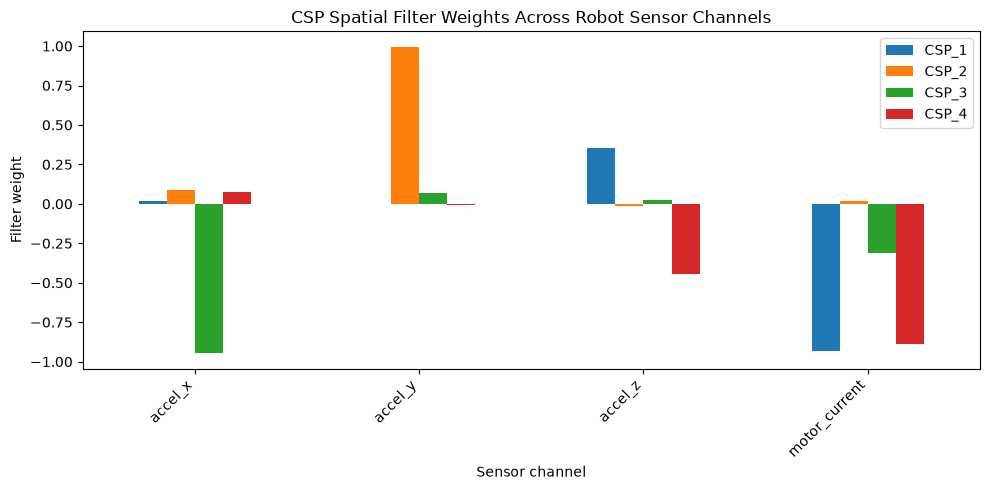

In [38]:
filter_names = [f"CSP_{i+1}" for i in range(W.shape[0])]
weights_df = pd.DataFrame(W, index=filter_names, columns=CHANNELS)

display(weights_df)

ax = weights_df.T.plot(kind="bar", figsize=(10, 5))
ax.set_title("CSP Spatial Filter Weights Across Robot Sensor Channels")
ax.set_xlabel("Sensor channel")
ax.set_ylabel("Filter weight")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 10. Apply CSP filters and extract log-variance features

For every window:

1. project the channels through `W`,
2. compute the variance of each CSP component,
3. normalize component variances,
4. take the log.

The result is one feature vector per sensor window.


In [39]:
def csp_logvar_features(X_windows, W, eps=1e-12):
    feature_rows = []

    for X in X_windows:
        Z = W @ X
        variances = np.var(Z, axis=1, ddof=1)

        # Standard CSP-style relative variance normalization.
        relative_var = variances / (variances.sum() + eps)
        logvar = np.log(relative_var + eps)

        feature_rows.append(logvar)

    return np.asarray(feature_rows)


X_csp = csp_logvar_features(X_windows, W)

print("CSP feature matrix shape:", X_csp.shape)
display(pd.DataFrame(X_csp, columns=filter_names).head())


CSP feature matrix shape: (478, 4)


,CSP_1,CSP_2,CSP_3,CSP_4
0,-2.557715,-0.681209,-1.280463,-1.976128
1,-2.600969,-0.690586,-1.255346,-1.969412
2,-2.577780,-0.735419,-1.107954,-2.167014
3,-2.349990,-0.926839,-0.891700,-2.313960
4,-2.478225,-0.759325,-1.013620,-2.462485


## 11. Construct raw baseline features

For a fair visual comparison, we also summarize each original sensor channel within a window using its log-variance.

This keeps the comparison focused on whether CSP's **cross-channel covariance projection** improves separation beyond the original channel representation.


In [40]:
def raw_logvar_features(X_windows, eps=1e-12):
    rows = []

    for X in X_windows:
        variances = np.var(X, axis=1, ddof=1)
        relative_var = variances / (variances.sum() + eps)
        rows.append(np.log(relative_var + eps))

    return np.asarray(rows)


X_raw = raw_logvar_features(X_windows)

raw_feature_names = [f"logvar_{c}" for c in CHANNELS]

print("Raw feature matrix shape:", X_raw.shape)
display(pd.DataFrame(X_raw, columns=raw_feature_names).head())


Raw feature matrix shape: (478, 4)


,logvar_accel_x,logvar_accel_y,logvar_accel_z,logvar_motor_current
0,-1.393141,-0.869567,-1.309425,-2.771027
1,-1.362408,-0.915579,-1.214245,-3.063204
2,-1.208753,-0.952007,-1.284102,-3.255387
3,-1.011617,-1.117974,-1.325385,-3.129783
4,-1.123972,-0.920996,-1.427930,-3.294495


## 12. Compare raw-feature vs CSP-feature separability

The Week 3 deliverable specifically asks whether the first two CSP feature dimensions produce cleaner class separation than the raw feature representation.


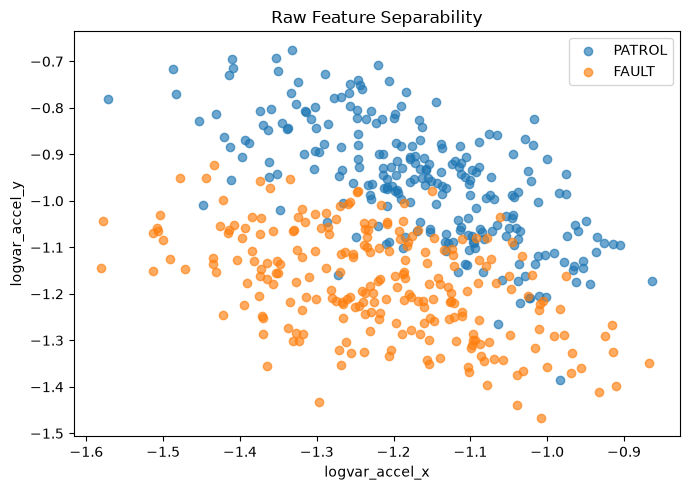

In [41]:
# Raw-feature scatter plot
plt.figure(figsize=(7, 5))

for cls in [CLASS_A, CLASS_B]:
    mask = y == cls
    plt.scatter(
        X_raw[mask, 0],
        X_raw[mask, 1],
        alpha=0.65,
        label=cls
    )

plt.xlabel(raw_feature_names[0])
plt.ylabel(raw_feature_names[1])
plt.title("Raw Feature Separability")
plt.legend()
plt.tight_layout()
plt.show()


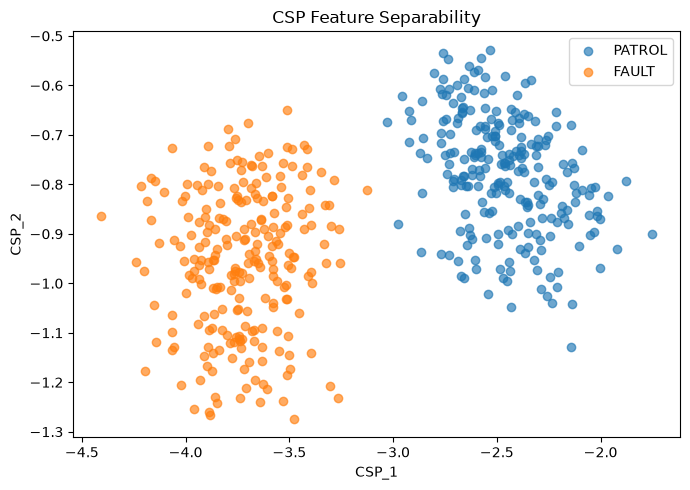

In [42]:
# CSP-feature scatter plot
plt.figure(figsize=(7, 5))

for cls in [CLASS_A, CLASS_B]:
    mask = y == cls
    plt.scatter(
        X_csp[mask, 0],
        X_csp[mask, 1],
        alpha=0.65,
        label=cls
    )

plt.xlabel(filter_names[0])
plt.ylabel(filter_names[1])
plt.title("CSP Feature Separability")
plt.legend()
plt.tight_layout()
plt.show()


## 13. Quick class-separation summary

This is only a descriptive check. Formal classification performance will be evaluated in `W03_LDA_Classifier.ipynb`.


In [43]:
csp_df = pd.DataFrame(X_csp, columns=filter_names)
csp_df["label"] = y

raw_df = pd.DataFrame(X_raw, columns=raw_feature_names)
raw_df["label"] = y

print("Mean CSP features by class:")
display(csp_df.groupby("label").mean())

print("Mean raw log-variance features by class:")
display(raw_df.groupby("label").mean())


Mean CSP features by class:


,CSP_1,CSP_2,CSP_3,CSP_4
label,,,,
FAULT,-3.726259,-0.955835,-1.086739,-1.437797
PATROL,-2.465384,-0.778243,-1.074265,-2.266871


Mean raw log-variance features by class:


,logvar_accel_x,logvar_accel_y,logvar_accel_z,logvar_motor_current
label,,,,
FAULT,-1.219384,-1.179200,-1.080989,-3.039167
PATROL,-1.165916,-0.959196,-1.384624,-3.094096


## 14. Save Week 3 feature matrices

The LDA notebook will load the saved CSP features and labels directly.

We also save the raw feature matrix so the Week 3 logistic-regression baseline uses the exact same windows.


In [44]:
output_dir = Path("data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

csp_out = pd.DataFrame(X_csp, columns=filter_names)
csp_out["label"] = y

raw_out = pd.DataFrame(X_raw, columns=raw_feature_names)
raw_out["label"] = y

# Preserve useful metadata when available.
if len(window_meta) == len(csp_out):
    if "unit" in window_meta.columns:
        csp_out.insert(0, "unit", window_meta["unit"].values)
        raw_out.insert(0, "unit", window_meta["unit"].values)

csp_path = output_dir / "W03_csp_features.csv"
raw_path = output_dir / "W03_raw_features.csv"

csp_out.to_csv(csp_path, index=False)
raw_out.to_csv(raw_path, index=False)

np.save(output_dir / "W03_csp_filters.npy", W)
np.save(output_dir / "W03_csp_eigenvalues.npy", all_eigvals)

print("Saved:")
print(" -", csp_path)
print(" -", raw_path)
print(" -", output_dir / "W03_csp_filters.npy")
print(" -", output_dir / "W03_csp_eigenvalues.npy")


Saved:
 - data/processed/W03_csp_features.csv
 - data/processed/W03_raw_features.csv
 - data/processed/W03_csp_filters.npy
 - data/processed/W03_csp_eigenvalues.npy


## 15. Interpretation checkpoint

After running the notebook, record the following observations for the methodology note and weekly recap:

- Are PATROL and FAULT more visibly separated after CSP?
- Which CSP components show the strongest separation?
- Which sensor channels receive large weights in the selected CSP filters?
- Does this suggest that operational modes differ in their **cross-sensor covariance structure**, rather than only in individual sensor magnitudes?
- Are there any remaining overlaps or outliers?

These observations will be connected to LDA performance in the next notebook.
